#TECH CHALLENGE – FASE 4
#MODELAGEM PREDITIVA PARA CLASSIFICAÇÃO DOS NÍVEIS DE OBESIDADE

####ALUNO: Victor Soares RM: 367299

####ALUNO: Cibele de Assis RM: 368525

####ALUNO: Alex Moreira RM: 367480

####ALUNO: José Ricardo RM: 367887

##OBJETIVO DA MODELAGEM
Esta etapa tem como finalidade desenvolver um modelo preditivo de Machine Learning para identificar e classificar os diferentes níveis de obesidade a partir de atributos físicos, hábitos de vida e características comportamentais dos indivíduos analisados.

Para garantir a consistência do processo analítico, o modelo será implementado por meio de uma pipeline de processamento, contemplando o tratamento adequado das variáveis e seguindo as especificações definidas no dicionário de dados da base utilizada.


In [1]:
import pandas as pd
import numpy as np
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [2]:
df = pd.read_csv("/content/drive/MyDrive/Obesity.csv")
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
df.tail()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
2106,Female,20.976842,1.710730,131.408528,yes,yes,3.0,3.0,Sometimes,no,1.728139,no,1.676269,0.906247,Sometimes,Public_Transportation,Obesity_Type_III
2107,Female,21.982942,1.748584,133.742943,yes,yes,3.0,3.0,Sometimes,no,2.005130,no,1.341390,0.599270,Sometimes,Public_Transportation,Obesity_Type_III
2108,Female,22.524036,1.752206,133.689352,yes,yes,3.0,3.0,Sometimes,no,2.054193,no,1.414209,0.646288,Sometimes,Public_Transportation,Obesity_Type_III
2109,Female,24.361936,1.739450,133.346641,yes,yes,3.0,3.0,Sometimes,no,2.852339,no,1.139107,0.586035,Sometimes,Public_Transportation,Obesity_Type_III
2110,Female,23.664709,1.738836,133.472641,yes,yes,3.0,3.0,Sometimes,no,2.863513,no,1.026452,0.714137,Sometimes,Public_Transportation,Obesity_Type_III


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

## ESTRUTURAÇÃO E CLASSIFICAÇÃO DAS VARIÁVEIS

Com base na documentação oficial da base de dados, as variáveis foram analisadas e categorizadas de acordo com suas características e níveis de mensuração.

As variáveis FCVC, NCP, CH2O, FAF e TUE foram classificadas como atributos numéricos ordinais, representando diferentes níveis de frequência ou intensidade. Já as variáveis family_history, FAVC, SMOKE e SCC foram identificadas como variáveis binárias, assumindo apenas duas categorias possíveis.

Por sua vez, CAEC e CALC correspondem a variáveis categóricas ordinais, uma vez que apresentam categorias com ordenação natural. A variável MTRANS foi considerada nominal, não possuindo relação hierárquica entre suas categorias. De forma semelhante, Gender foi tratada como uma variável categórica nominal.

A definição dessas classificações é fundamental para garantir a aplicação adequada das técnicas de pré-processamento e codificação durante a etapa de modelagem.


In [5]:
# Arredondamento de variáveis ordinais numéricas
colunas_ordinais = ["FCVC", "NCP", "CH2O", "FAF", "TUE"]

for col in colunas_ordinais:
    df[col] = df[col].round()

# Conversão de variáveis binárias (yes/no → 1/0)
binarias = ["family_history", "FAVC", "SMOKE", "SCC"]

for col in binarias:
    df[col] = df[col].map({"yes": 1, "no": 0})

# Mapeamento de variáveis ordinais textuais
df["CAEC"] = df["CAEC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})
df["CALC"] = df["CALC"].map({"no":0, "Sometimes":1, "Frequently":2, "Always":3})

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,1,0,2.0,3.0,1,0,2.0,0,0.0,1.0,0,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,1,0,3.0,3.0,1,1,3.0,1,3.0,0.0,1,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,1,0,2.0,3.0,1,0,2.0,0,2.0,1.0,2,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,0,0,3.0,3.0,1,0,2.0,0,2.0,0.0,2,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,0,0,2.0,1.0,1,0,2.0,0,0.0,0.0,1,Public_Transportation,Overweight_Level_II


## DESENVOLVIMENTO DE VARIÁVEIS DERIVADAS

Com o propósito de ampliar o potencial explicativo da base de dados, foi incorporado o Índice de Massa Corporal (IMC) como uma nova variável derivada. Essa métrica é amplamente reconhecida na literatura médica e epidemiológica como um dos principais parâmetros utilizados na avaliação do estado nutricional e na identificação de diferentes níveis de obesidade.

O cálculo do indicador foi realizado a partir da relação entre o peso corporal e a altura do indivíduo elevada ao quadrado, permitindo uma representação mais objetiva da composição corporal dos participantes analisados.

**Equação utilizada:**

IMC = Peso (kg) / Altura² (m)

A inclusão dessa variável busca fornecer informações adicionais relevantes para o processo de modelagem, contribuindo para uma melhor caracterização dos padrões associados à obesidade.


In [6]:
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

X = df.drop("Obesity", axis=1)
y = df["Obesity"]

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (1688, 17)
Teste: (423, 17)


## DEFINIÇÃO DOS GRUPOS DE VARIÁVEIS
Com o objetivo de otimizar as etapas de pré-processamento, os atributos foram segmentados em grupos distintos de acordo com sua natureza.

Essa organização permite aplicar transformações específicas para cada conjunto de variáveis, garantindo que características numéricas e categóricas sejam tratadas adequadamente durante o treinamento do modelo.



In [8]:
colunas_numericas = [
    "Age", "Height", "Weight",
    "FCVC", "NCP", "CH2O",
    "FAF", "TUE", "BMI",
    "family_history", "FAVC",
    "SMOKE", "SCC",
    "CAEC", "CALC"
]

colunas_nominais = ["Gender", "MTRANS"]

## DESENVOLVIMENTO DA PIPELINE DE PROCESSAMENTO
Com o intuito de garantir consistência e reprodutibilidade ao processo de modelagem, foi construída uma pipeline integrada de pré-processamento e treinamento.

Essa abordagem permite automatizar a transformação dos dados e assegurar que os mesmos procedimentos aplicados durante o treinamento sejam replicados em futuras previsões. Além disso, a utilização de pipelines reduz a ocorrência de inconsistências e facilita a manutenção do fluxo analítico.


In [9]:
preprocessador = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), colunas_numericas),
        ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_nominais)
    ]
)

modelo = RandomForestClassifier(
    n_estimators=300,
    random_state=42
)

pipeline = Pipeline(
    steps=[
        ("preprocessamento", preprocessador),
        ("modelo", modelo)
    ]
)

pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessamento',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  ['Age', 'Height', 'Weight',
                                                   'FCVC', 'NCP', 'CH2O', 'FAF',
                                                   'TUE', 'BMI',
                                                   'family_history', 'FAVC',
                                                   'SMOKE', 'SCC', 'CAEC',
                                                   'CALC']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Gender', 'MTRANS'])])),
                ('modelo',
                 RandomForestClassifier(n_estimators=300, random_state=42))])

## DESEMPENHO E VALIDAÇÃO DO MODELO
Os resultados obtidos evidenciam a capacidade do modelo Random Forest em identificar corretamente os diferentes níveis de obesidade presentes na base de dados. O desempenho alcançado superou com ampla margem o critério mínimo de acurácia estabelecido para o desafio, demonstrando elevada eficiência no processo de classificação.

A incorporação do Índice de Massa Corporal (IMC) ao conjunto de atributos contribuiu significativamente para a qualidade das previsões, reforçando sua relevância como indicador associado à condição de obesidade.

De forma geral, o modelo apresentou elevado poder discriminatório entre as classes analisadas, indicando potencial para aplicações voltadas à análise de perfis de risco e suporte a processos de tomada de decisão fundamentados em dados.


In [ ]:
y_pred = pipeline.predict(X_test)

print("Acurácia:", accuracy_score(y_test, y_pred))
print("\nRelatório de Classificação:")
print(classification_report(y_test, y_pred))
print("\nMatriz de Confusão:")
print(confusion_matrix(y_test, y_pred))


Acurácia: 0.9881796690307328

Relatório de Classificação:
                     precision    recall  f1-score   support

Insufficient_Weight       1.00      0.98      0.99        54
      Normal_Weight       0.95      0.98      0.97        58
     Obesity_Type_I       1.00      1.00      1.00        70
    Obesity_Type_II       0.98      1.00      0.99        60
   Obesity_Type_III       1.00      0.98      0.99        65
 Overweight_Level_I       0.98      0.97      0.97        58
Overweight_Level_II       1.00      1.00      1.00        58

           accuracy                           0.99       423
          macro avg       0.99      0.99      0.99       423
       weighted avg       0.99      0.99      0.99       423


Matriz de Confusão:
[[53  1  0  0  0  0  0]
 [ 0 57  0  0  0  1  0]
 [ 0  0 70  0  0  0  0]
 [ 0  0  0 60  0  0  0]
 [ 0  0  0  1 64  0  0]
 [ 0  2  0  0  0 56  0]
 [ 0  0  0  0  0  0 58]]


## ANÁLISE EXPLORATÓRIA DOS RESULTADOS


In [10]:
joblib.dump(pipeline, "/content/drive/MyDrive/obesity_model.pkl")

['/content/drive/MyDrive/obesity_model.pkl']

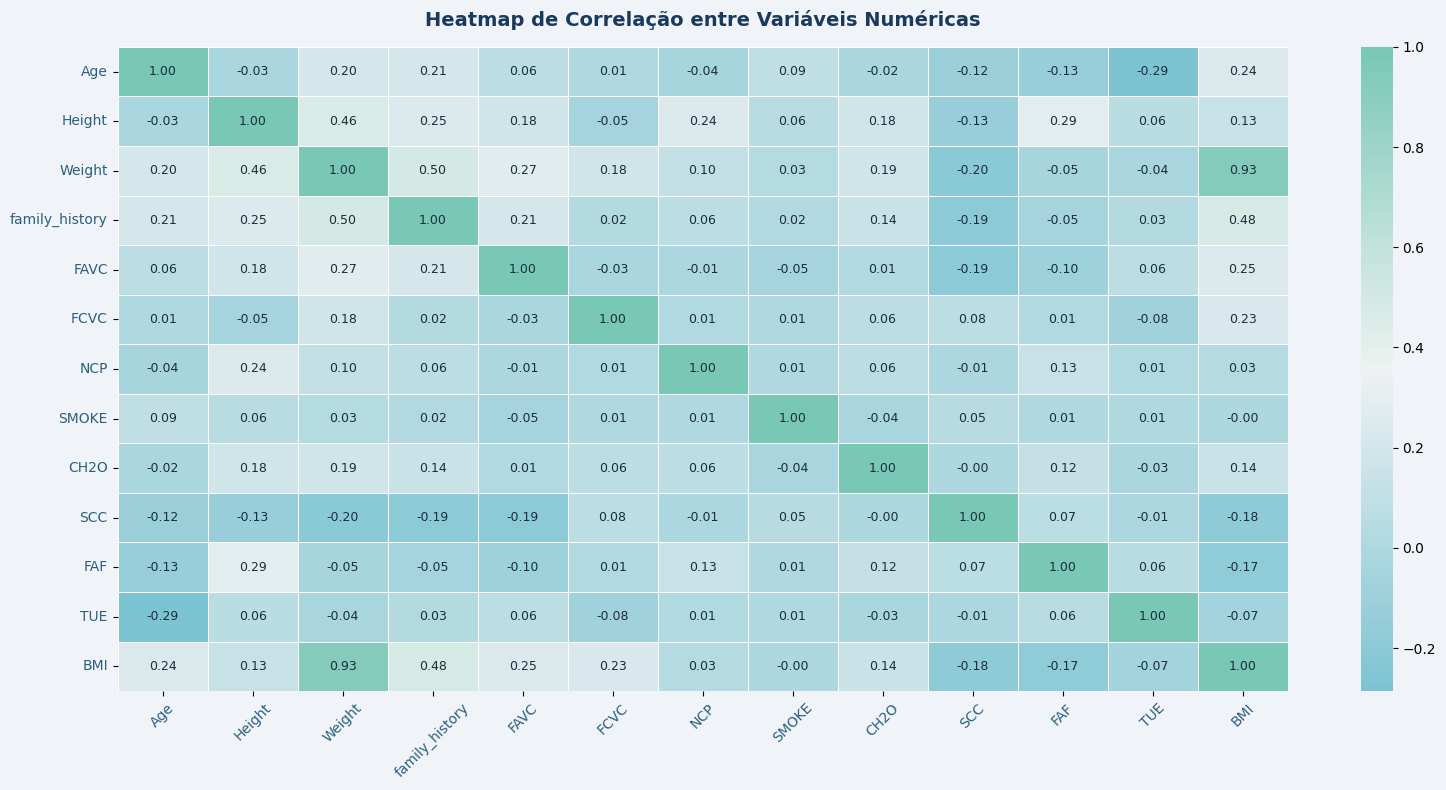

In [11]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remover variáveis originalmente categóricas
df_temp = df.drop(columns=['CAEC', 'CALC']).copy()

# Calcular matriz de correlação apenas para numéricas
corr_temp = df_temp.corr(numeric_only=True)

# Paleta hospitalar: azul-claro → branco → verde-azulado
hospital_cmap = sns.diverging_palette(210, 170, s=60, l=75, as_cmap=True)

# Plotar heatmap
plt.figure(figsize=(16, 8), facecolor='#F0F4F8')  # fundo cinza-azulado claro

ax = sns.heatmap(
    corr_temp,
    annot=True,
    cmap=hospital_cmap,
    fmt=".2f",
    linewidths=0.5,
    linecolor='#FFFFFF',
    annot_kws={"size": 9, "color": "#1A2E3B"},  # texto azul-escuro
    ax=plt.gca()
)

ax.set_facecolor('#F0F4F8')  # fundo interno igual ao externo

plt.title(
    'Heatmap de Correlação entre Variáveis Numéricas',
    fontsize=14,
    color='#1A3A5C',        # título azul-marinho
    fontweight='bold',
    pad=15
)

plt.xticks(rotation=45, color='#2C5F7A')  # eixos em azul-médio
plt.yticks(rotation=0,  color='#2C5F7A')
plt.tight_layout()
plt.show()

####Interpretação da Matriz de Correlação
A matriz de correlação permite identificar o grau de associação linear existente entre as variáveis numéricas da base de dados. A análise evidencia relações positivas e negativas entre determinados atributos, fornecendo uma visão inicial sobre os fatores potencialmente associados aos diferentes níveis de obesidade.

Essas informações complementam a etapa de modelagem ao oferecer evidências quantitativas sobre a interação entre as variáveis analisadas.


##RELAÇÃO ENTRE AS VARIÁVEIS E O IMC


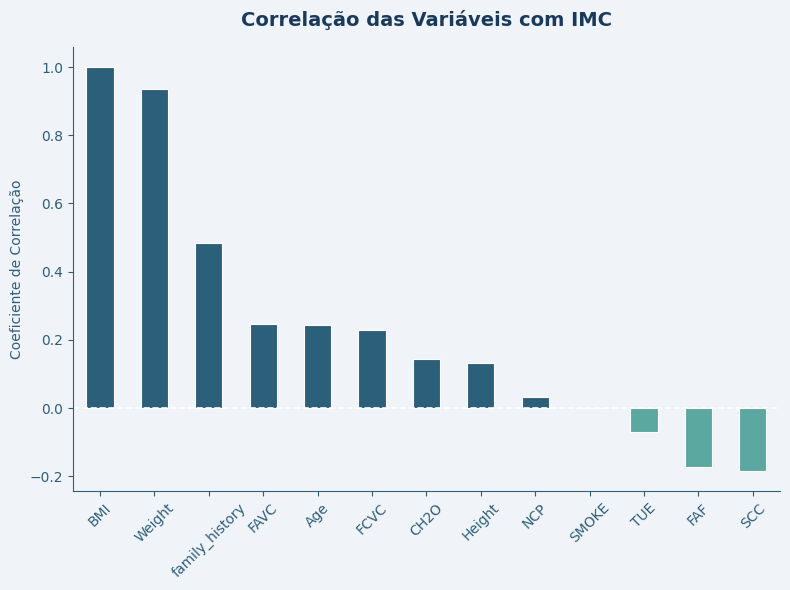

In [12]:
corr_ordenada = corr_temp["BMI"].sort_values(ascending=False)

# Paleta hospitalar baseada nos valores (positivo=azul, negativo=verde-água)
cores = ['#2C5F7A' if v >= 0 else '#5BA8A0' for v in corr_ordenada.values]

fig, ax = plt.subplots(figsize=(8, 6), facecolor='#F0F4F8')
ax.set_facecolor('#F0F4F8')

corr_ordenada.plot(kind="bar", ax=ax, color=cores, edgecolor='#FFFFFF', linewidth=0.8)

ax.set_title(
    "Correlação das Variáveis com IMC",
    fontsize=14,
    fontweight='bold',
    color='#1A3A5C',
    pad=15
)
ax.set_ylabel("Coeficiente de Correlação", color='#2C5F7A')
ax.tick_params(colors='#2C5F7A')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#2C5F7A')
ax.axhline(0, color='#FFFFFF', linewidth=1.2, linestyle='--')

plt.xticks(rotation=45, color='#2C5F7A')
plt.tight_layout()
plt.show()

####Discussão dos Resultados
A avaliação dos coeficientes de correlação permite identificar quais características apresentam maior associação com o Índice de Massa Corporal. Observa-se que determinadas variáveis demonstram relações mais expressivas, indicando potencial relevância na caracterização dos diferentes perfis de obesidade.

Essa análise complementa a etapa de modelagem ao fornecer evidências quantitativas sobre os atributos mais relacionados ao fenômeno estudado.


## IMPORTÂNCIA DAS VARIÁVEIS NO MODELO

In [13]:
# Recuperar modelo treinado dentro da pipeline
modelo_rf = pipeline.named_steps["modelo"]

# Recuperar nomes das features após preprocessamento
feature_names_num = colunas_numericas
feature_names_cat = pipeline.named_steps["preprocessamento"] \
    .named_transformers_["cat"] \
    .get_feature_names_out(colunas_nominais)
feature_names = list(feature_names_num) + list(feature_names_cat)

# Importâncias
importancias = modelo_rf.feature_importances_

# Criar DataFrame
df_importancia = pd.DataFrame({
    "Variavel": feature_names,
    "Importancia": importancias
}).sort_values(by="Importancia", ascending=False)

# Estilo premium hospitalar com texto branco
(df_importancia.head(10)
    .style
    .background_gradient(
        subset=["Importancia"],
        cmap=sns.light_palette("#2C5F7A", as_cmap=True)
    )
    .format({"Importancia": "{:.4f}"})
    .set_caption("Top 10 Variáveis Mais Importantes")
    .set_properties(**{
        "color": "#FFFFFF",
        "background-color": "#1A3A5C",
    })
    .set_table_styles([
        # Caption
        {"selector": "caption",
         "props": [("color", "#FFFFFF"),
                   ("font-size", "15px"),
                   ("font-weight", "bold"),
                   ("padding-bottom", "10px"),
                   ("text-align", "left"),
                   ("letter-spacing", "0.5px")]},
        # Cabeçalho
        {"selector": "thead th",
         "props": [("background-color", "#0F2336"),
                   ("color", "#FFFFFF"),
                   ("font-size", "12px"),
                   ("font-weight", "600"),
                   ("letter-spacing", "0.8px"),
                   ("text-transform", "uppercase"),
                   ("padding", "10px 16px"),
                   ("border", "none")]},
        # Índice
        {"selector": "th.row_heading",
         "props": [("background-color", "#1A3A5C"),
                   ("color", "#FFFFFF"),
                   ("font-weight", "600"),
                   ("padding", "9px 16px"),
                   ("border-bottom", "1px solid #2C5F7A")]},
        # Células
        {"selector": "tbody td",
         "props": [("padding", "9px 16px"),
                   ("font-size", "13px"),
                   ("color", "#FFFFFF"),
                   ("border-bottom", "1px solid #2C5F7A")]},
        # Hover
        {"selector": "tbody tr:hover td",
         "props": [("background-color", "#2C5F7A !important"),
                   ("color", "#FFFFFF !important"),
                   ("transition", "background 0.2s")]},
        # Tabela geral
        {"selector": "table",
         "props": [("border-collapse", "collapse"),
                   ("background-color", "#1A3A5C"),
                   ("border-radius", "8px"),
                   ("overflow", "hidden"),
                   ("box-shadow", "0 2px 12px rgba(0,0,0,0.30)")]},
    ])
)

,Variavel,Importancia
8,BMI,0.3738
2,Weight,0.2235
0,Age,0.0657
1,Height,0.0605
16,Gender_Male,0.0405
15,Gender_Female,0.0329
13,CAEC,0.0271
14,CALC,0.0246
9,family_history,0.0231
3,FCVC,0.0212


####Interpretação da Importância dos Atributos
A análise de importância das variáveis permite compreender quais atributos exerceram maior influência nas decisões do modelo Random Forest. Os resultados demonstram que determinadas características contribuíram de forma mais significativa para a classificação dos níveis de obesidade.

Além de aumentar a interpretabilidade do modelo, essa avaliação auxilia na identificação dos fatores mais relevantes para a compreensão do fenômeno analisado.


## DISTRIBUIÇÃO DO IMC ENTRE AS CLASSES DE OBESIDADE

/tmp/ipykernel_10653/916527991.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_10653/916527991.py:16: UserWarning: The palette list has more values (8) than needed (7), which may not be intended.
  sns.boxplot(


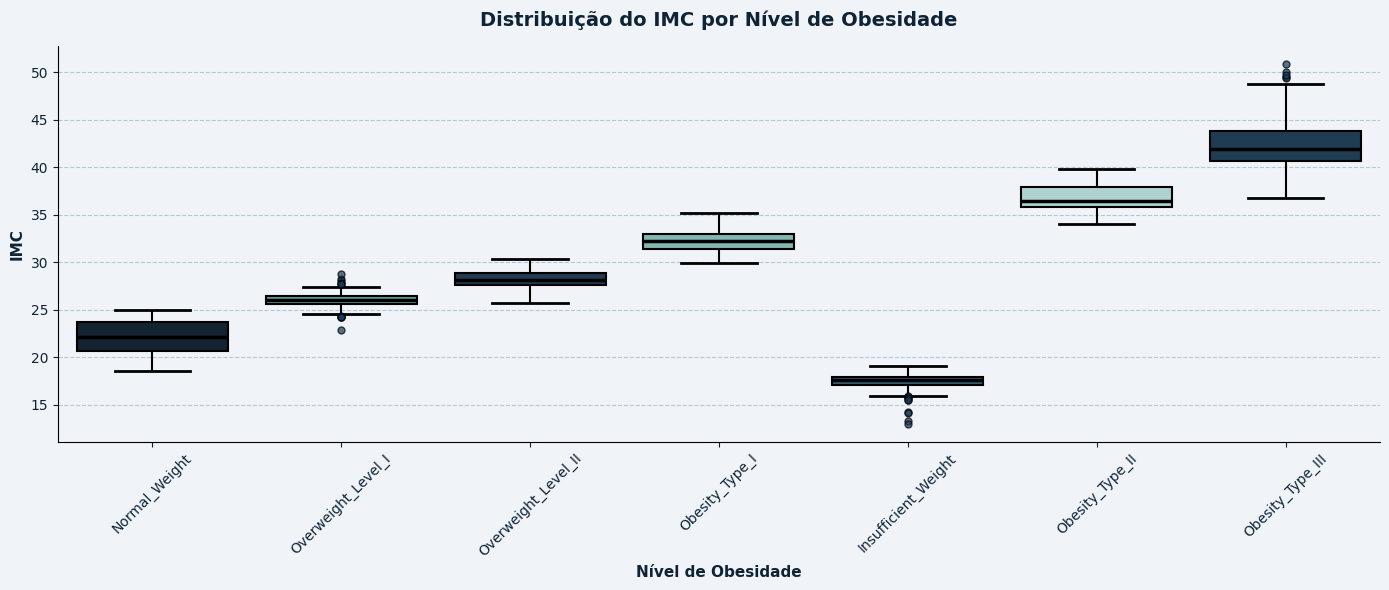

In [15]:
# Paleta alternando tons claros e escuros
hospital_palette = [
    "#0F2336",  # escuro
    "#5BA8A0",  # claro
    "#1A3A5C",  # escuro
    "#7ABFB8",  # claro
    "#2C5F7A",  # médio-escuro
    "#A8D8D4",  # claro
    "#163D5A",  # escuro
    "#3D7A96",  # médio
]

fig, ax = plt.subplots(figsize=(14, 6), facecolor='#F0F4F8')
ax.set_facecolor('#F0F4F8')

sns.boxplot(
    data=df,
    x="Obesity",
    y="BMI",
    palette=hospital_palette,
    linewidth=1.5,
    flierprops=dict(
        marker='o',
        markerfacecolor='#1A3A5C',
        markeredgecolor='#000000',
        markersize=5,
        alpha=0.7
    ),
    boxprops=dict(edgecolor='#000000', linewidth=1.5),
    whiskerprops=dict(color='#000000', linewidth=1.5),
    capprops=dict(color='#000000', linewidth=2),
    medianprops=dict(color='#000000', linewidth=2.5),
    ax=ax
)

ax.set_title(
    "Distribuição do IMC por Nível de Obesidade",
    fontsize=14,
    fontweight='bold',
    color='#0F2336',
    pad=15
)
ax.set_xlabel("Nível de Obesidade", color='#0F2336', fontsize=11, fontweight='600')
ax.set_ylabel("IMC", color='#0F2336', fontsize=11, fontweight='600')

ax.tick_params(colors='#0F2336')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#000000')

ax.yaxis.grid(True, color='#B0C8D8', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

plt.xticks(rotation=45, color='#0F2336', fontweight='500')
plt.yticks(color='#0F2336')
plt.tight_layout()
plt.show()

#### Interpretação dos Resultados
Observa-se uma diferenciação progressiva dos valores de IMC entre as categorias analisadas, evidenciando um padrão consistente de crescimento conforme o aumento do nível de obesidade.

Esse comportamento reforça a coerência dos dados utilizados no estudo e demonstra a relevância do IMC como indicador para a distinção entre os diferentes grupos avaliados.


## ATIVIDADE FÍSICA E NÍVEIS DE OBESIDADE


/tmp/ipykernel_10653/3159683046.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


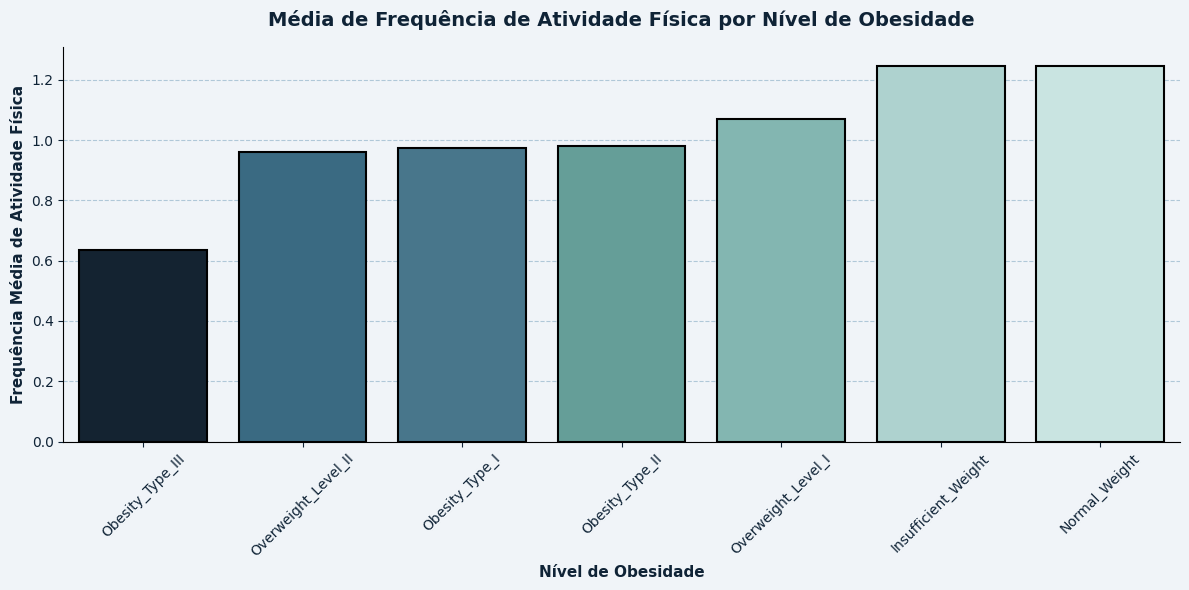

In [17]:
# Paleta com 7 cores únicas — sem repetição
hospital_palette_faf = [
    "#0F2336",  # azul-marinho profundo
    "#2E6E8E",  # azul-aço
    "#3D7A96",  # azul-médio
    "#5BA8A0",  # verde-água médio
    "#7ABFB8",  # verde-água suave
    "#A8D8D4",  # verde-água claro
    "#C5E8E5",  # verde-água muito claro
]

media_faf = df.groupby("Obesity")["FAF"].mean().sort_values()

fig, ax = plt.subplots(figsize=(12, 6), facecolor='#F0F4F8')
ax.set_facecolor('#F0F4F8')

sns.barplot(
    x=media_faf.index,
    y=media_faf.values,
    palette=hospital_palette_faf[:len(media_faf)],
    edgecolor='#000000',
    linewidth=1.5,
    ax=ax
)

ax.set_title(
    "Média de Frequência de Atividade Física por Nível de Obesidade",
    fontsize=14,
    fontweight='bold',
    color='#0F2336',
    pad=15
)
ax.set_xlabel("Nível de Obesidade", color='#0F2336', fontsize=11, fontweight='600')
ax.set_ylabel("Frequência Média de Atividade Física", color='#0F2336', fontsize=11, fontweight='600')

ax.tick_params(colors='#0F2336')
ax.spines[['top', 'right']].set_visible(False)
ax.spines[['left', 'bottom']].set_color('#000000')

ax.yaxis.grid(True, color='#B0C8D8', linewidth=0.8, linestyle='--')
ax.set_axisbelow(True)

plt.xticks(rotation=45, color='#0F2336', fontweight='500')
plt.yticks(color='#0F2336')
plt.tight_layout()
plt.show()

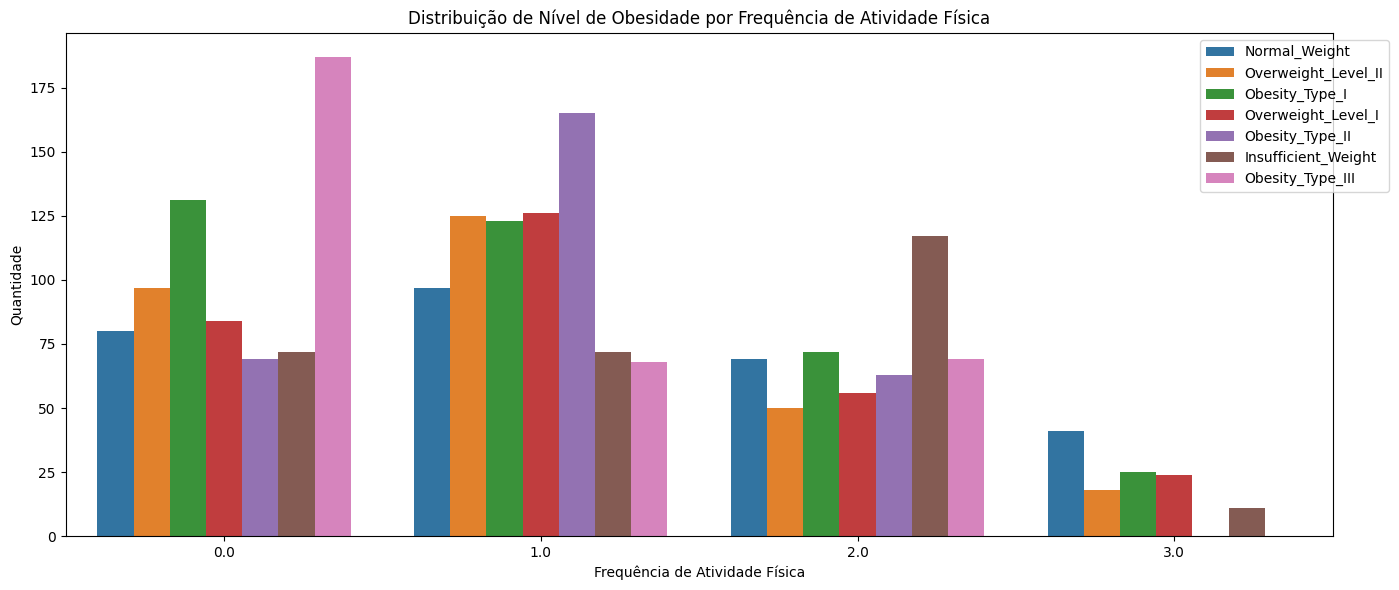

In [18]:
plt.figure(figsize=(14,6))

sns.countplot(
    data=df,
    x="FAF",
    hue="Obesity"
)

plt.title("Distribuição de Nível de Obesidade por Frequência de Atividade Física")
plt.xlabel("Frequência de Atividade Física")
plt.ylabel("Quantidade")
plt.legend(bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

####Discussão dos Achados
A análise da frequência de atividade física sugere a existência de uma relação entre a prática regular de exercícios e os níveis de obesidade observados na amostra.

De maneira geral, indivíduos classificados em categorias mais severas tendem a apresentar menores níveis médios de atividade física, evidenciando a relevância desse fator comportamental na compreensão dos padrões associados à obesidade.


## PREPARAÇÃO DOS DADOS PARA VISUALIZAÇÃO NO LOOKER STUDIO

In [19]:
# ==========================================================
# GERAÇÃO DE EXCEL ANALÍTICO PARA DASHBOARD
# ==========================================================

import pandas as pd

# Criar análises

dist_obesity = df["Obesity"].value_counts().reset_index()
dist_obesity.columns = ["Obesity_Level", "Count"]

media_bmi = df.groupby("Obesity")["BMI"].mean().reset_index()
media_bmi.columns = ["Obesity_Level", "Average_BMI"]

media_faf = df.groupby("Obesity")["FAF"].mean().reset_index()
media_faf.columns = ["Obesity_Level", "Average_Physical_Activity"]

historico_familiar = (
    df.groupby(["Obesity", "family_history"])
    .size()
    .reset_index(name="Count")
)

consumo_agua = df.groupby("Obesity")["CH2O"].mean().reset_index()
consumo_agua.columns = ["Obesity_Level", "Average_Water_Consumption"]

tempo_tela = df.groupby("Obesity")["TUE"].mean().reset_index()
tempo_tela.columns = ["Obesity_Level", "Average_Device_Time"]

# ==========================================================
# EXPORTAR PARA EXCEL COM MÚLTIPLAS ABAS
# ==========================================================

with pd.ExcelWriter("dashboard_obesidade.xlsx") as writer:
    df.to_excel(writer, sheet_name="Base_Completa", index=False)
    dist_obesity.to_excel(writer, sheet_name="Distribuicao_Obesidade", index=False)
    media_bmi.to_excel(writer, sheet_name="IMC_por_Classe", index=False)
    media_faf.to_excel(writer, sheet_name="Atividade_Fisica", index=False)
    historico_familiar.to_excel(writer, sheet_name="Historico_Familiar", index=False)
    consumo_agua.to_excel(writer, sheet_name="Consumo_Agua", index=False)
    tempo_tela.to_excel(writer, sheet_name="Tempo_Tela", index=False)

print("Arquivo 'dashboard_obesidade.xlsx' criado com sucesso!")

Arquivo 'dashboard_obesidade.xlsx' criado com sucesso!


## TRATAMENTO E PADRONIZAÇÃO DOS DADOS PARA O DASHBOARD

In [20]:
# ==========================================================
# TRADUÇÃO COMPLETA DOS CAMPOS E VALORES
# ==========================================================

df_dashboard = df.copy()

# =========================
# 1️⃣ RENOMEAR COLUNAS
# =========================

df_dashboard = df_dashboard.rename(columns={
    "Age": "Idade",
    "BMI": "IMC",
    "CAEC": "Consumo_Entre_Refeicoes",
    "CALC": "Consumo_Alcool",
    "CH2O": "Consumo_Agua",
    "FAF": "Frequencia_Atividade_Fisica",
    "family_history": "Historico_Familiar",
    "FAVC": "Consumo_Alto_Calorico",
    "FCVC": "Consumo_Vegetais",
    "Gender": "Genero",
    "Height": "Altura",
    "MTRANS": "Meio_Transporte",
    "NCP": "Numero_Refeicoes",
    "Obesity": "Nivel_Obesidade",
    "SCC": "Monitora_Calorias",
    "SMOKE": "Fumante",
    "TUE": "Tempo_Tela",
    "Weight": "Peso"
})

# =========================
# 2️⃣ TRADUZIR VALORES
# =========================

# Gênero
df_dashboard["Genero"] = df_dashboard["Genero"].replace({
    "Male": "Masculino",
    "Female": "Feminino"
})

# Histórico familiar
df_dashboard["Historico_Familiar"] = df_dashboard["Historico_Familiar"].replace({
    1: "Sim",
    0: "Não"
})

# Fumante
df_dashboard["Fumante"] = df_dashboard["Fumante"].replace({
    1: "Sim",
    0: "Não"
})

# Monitora calorias
df_dashboard["Monitora_Calorias"] = df_dashboard["Monitora_Calorias"].replace({
    1: "Sim",
    0: "Não"
})

# Consumo alto calórico
df_dashboard["Consumo_Alto_Calorico"] = df_dashboard["Consumo_Alto_Calorico"].replace({
    1: "Sim",
    0: "Não"
})

# Consumo entre refeições
df_dashboard["Consumo_Entre_Refeicoes"] = df_dashboard["Consumo_Entre_Refeicoes"].replace({
    0: "Nunca",
    1: "Às vezes",
    2: "Frequentemente",
    3: "Sempre"
})

# Consumo álcool
df_dashboard["Consumo_Alcool"] = df_dashboard["Consumo_Alcool"].replace({
    0: "Não consome",
    1: "Às vezes",
    2: "Frequentemente",
    3: "Sempre"
})

# Meio de transporte
df_dashboard["Meio_Transporte"] = df_dashboard["Meio_Transporte"].replace({
    "Automobile": "Carro",
    "Motorbike": "Moto",
    "Bike": "Bicicleta",
    "Public_Transportation": "Transporte Público",
    "Walking": "A pé"
})

# Traduzir nível de obesidade
df_dashboard["Nivel_Obesidade"] = df_dashboard["Nivel_Obesidade"].replace({
    "Insufficient_Weight": "Abaixo do Peso",
    "Normal_Weight": "Peso Normal",
    "Overweight_Level_I": "Sobrepeso Nível I",
    "Overweight_Level_II": "Sobrepeso Nível II",
    "Obesity_Type_I": "Obesidade Tipo I",
    "Obesity_Type_II": "Obesidade Tipo II",
    "Obesity_Type_III": "Obesidade Tipo III"
})

# ==========================================================
# 3️⃣ EXPORTAR EXCEL FINAL LIMPO
# ==========================================================

df_dashboard.to_excel("dashboard_obesidade_paralooker.xlsx", index=False)

print("Arquivo 'dashboard_obesidade_paralooker.xlsx' criado com sucesso!")

Arquivo 'dashboard_obesidade_paralooker.xlsx' criado com sucesso!


## EXPORTAÇÃO DOS ARQUIVOS FINAIS

In [21]:
joblib.dump(pipeline, "obesity_model.pkl")

['obesity_model.pkl']

In [22]:
from google.colab import files
files.download("obesity_model.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [23]:
from google.colab import files
files.download("dashboard_obesidade_paralooker.xlsx")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>